In [2]:
from femviz import femModel, _plot_control_tripcolor, _plot_state_pcolormesh
from matplotlib import pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
fm = femModel(alpha=0.01, n=64)

In [3]:
fm.objective

0.7960990013841786

In [4]:
fm.objective_cont

1.4862597911794024

In [6]:
fm.tv

157.61574669941334

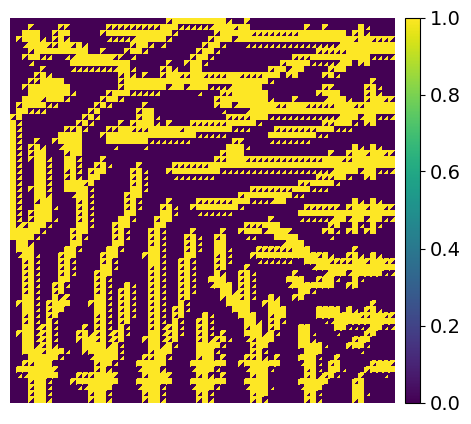

In [4]:
fm.plot_control()

In [ ]:
def transpose_control(ax, im):
    # --- Make the plotted field fill the axes tightly ---
    ax.set_aspect("equal", adjustable="box")
    ax.margins(0)

    # For pcolormesh, this reliably tightens limits to the mesh extent
    ax.relim()
    ax.autoscale_view(tight=True)

    # Remove any extra padding that some helper functions introduce
    try:
        ax.set_xlim(*im.axes.dataLim.intervalx)
        ax.set_ylim(*im.axes.dataLim.intervaly)
    except Exception:
        pass

    # --- Colorbar: same height as the axes, small gap ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.1)

    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=14)
    #cbar.set_label("u(x)", fontsize=14)

    # No border/ticks
    ax.set_axis_off()

    # Avoid tight_layout (it can fight the appended cax)

In [ ]:
def transpose_state(ax, im):
    # --- Make the plotted field fill the axes tightly ---
    ax.set_aspect("equal", adjustable="box")
    ax.margins(0)

    # For pcolormesh, this reliably tightens limits to the mesh extent
    ax.relim()
    ax.autoscale_view(tight=True)

    # Remove any extra padding that some helper functions introduce
    try:
        ax.set_xlim(*im.axes.dataLim.intervalx)
        ax.set_ylim(*im.axes.dataLim.intervaly)
    except Exception:
        pass

    # --- Colorbar: same height as the axes, small gap ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.1)

    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=14)
    #cbar.set_label("u(x)", fontsize=14)

    # No border/ticks
    ax.set_axis_off()

    # Avoid tight_layout (it can fight the appended cax)

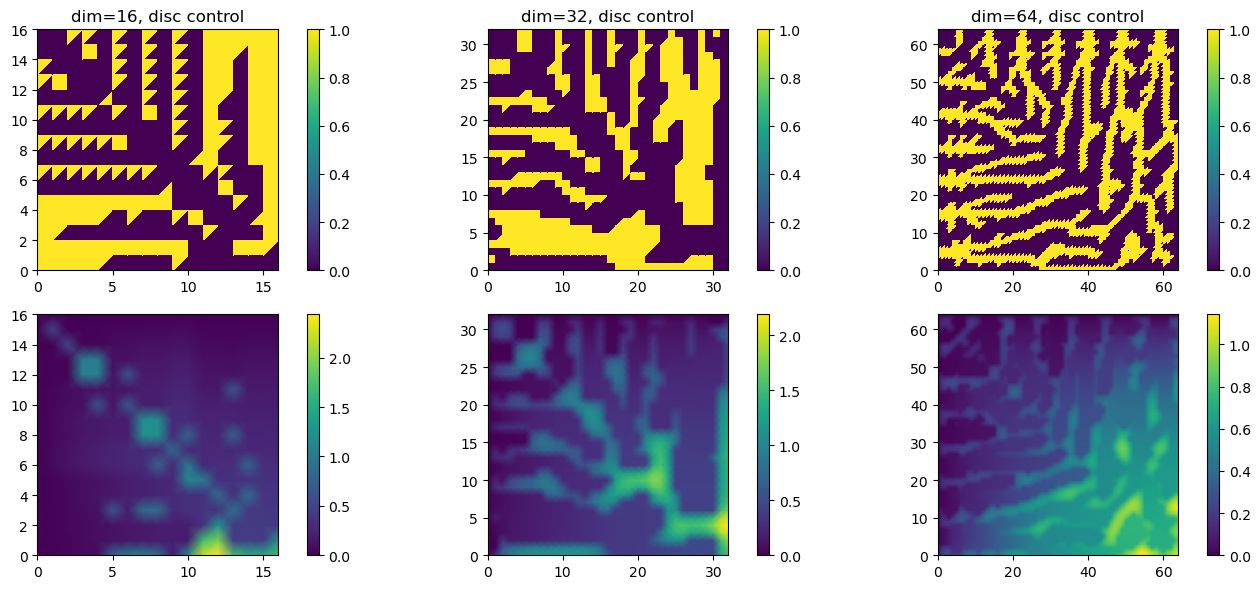

In [3]:
mesh_list = [16,32,64]
fig,ax = plt.subplots(figsize=(15,6), nrows=2, ncols=3)
for i, mesh in enumerate(mesh_list):
    fm = femModel(alpha=0.01, n=mesh, base_dir="fem_model_tri")
    c = fm.control
    s = fm.state
    im_c = _plot_control_tripcolor(ax=ax[0][i], a=c, n=mesh, title=f"dim={mesh}, disc control")
    #fig.colorbar(im_c, ax=ax[0][i])
    im_s = _plot_state_pcolormesh(ax=ax[1][i], u=s, n=mesh, title=f"dim={mesh}, state")
    fig.colorbar(im_s, ax=ax[1][i])
    plt.tight_layout() 

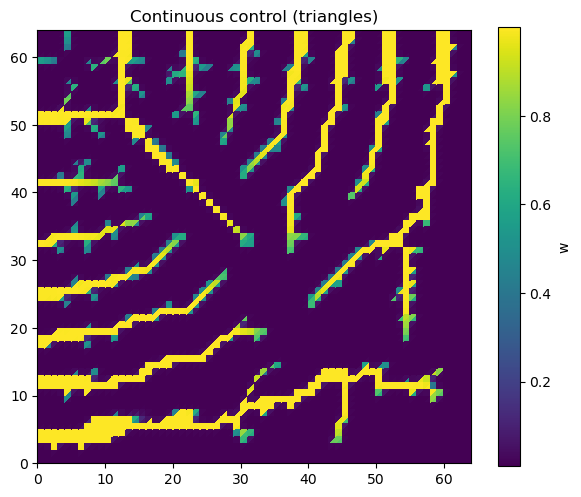

In [45]:
fm.plot_control(cont=True)

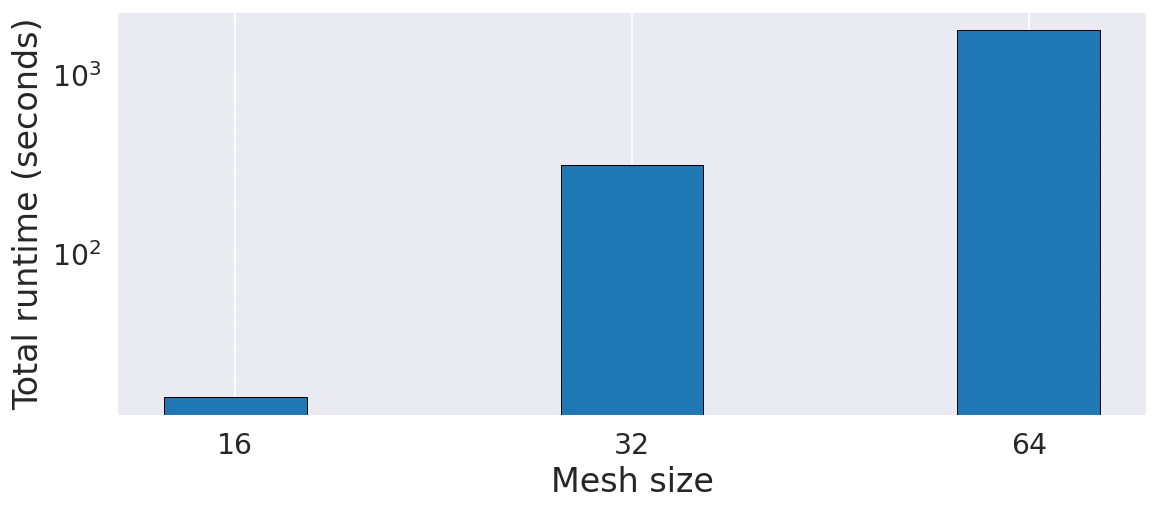

mesh= 16 | runtime=1.593e+01 s
mesh= 32 | runtime=3.167e+02 s
mesh= 64 | runtime=1.782e+03 s


In [5]:
# Runtime comparison across mesh sizes
mesh_sizes = [16, 32, 64]
base_dir = "fem_model_tri"
alpha = 0.01

runtime = []

for mesh in mesh_sizes:
    fm = femModel(alpha=alpha, n=mesh, base_dir=base_dir)
    runtime.append(float(fm.runtime_total))

runtime = np.asarray(runtime, dtype=float)


# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,

    # line/bar style
    "lines.linewidth": 2.8,
    "lines.markersize": 6,

    # global font sizes
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "legend.title_fontsize": 17,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
color_runtime = cmap(0)


x = np.arange(len(mesh_sizes))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x,
    runtime,
    width=width,
    color=color_runtime,
    edgecolor="black",
    linewidth=0.6,
    label="Total runtime",
)

ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in mesh_sizes])
ax.set_xlabel("Mesh size")
ax.set_ylabel("Total runtime (seconds)")
ax.set_yscale("log")

ax.grid(
    True,
    axis="y",
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# ax.legend(
#     loc="upper center",
#     bbox_to_anchor=(0.5, 0.14),
#     ncol=1,
#     frameon=True,
# )

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()


for mesh, r in zip(mesh_sizes, runtime):
    print(f"mesh={mesh:>3} | runtime={r:.3e} s")